# PothRGDB EDA for Severity Analysis

This notebook is the first EDA pass for the project. The scope is intentionally narrow: understand what the PothRGDB dataset supports for severity-oriented analysis before any 2D-to-3D conversion or model selection work.

Main questions:
- How complete and consistent is the dataset?
- What do the depth, area, and volume distributions look like?
- Which samples look like outliers or likely data-quality issues?

In [1]:
import sys
import json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

candidate_roots = [d for d in Path.cwd().parents if d.name == "multimodal-pothole-detection"]
if len(candidate_roots) == 0:
    if Path.cwd().name == "multimodal-pothole-detection":
        code_root = Path.cwd()
    else:
        raise RuntimeError("Notebook needs to be run within the multimodal-pothole-detection project.")
else:
    code_root = candidate_roots[-1]

scripts_root = code_root / "src" / "scripts"
if str(scripts_root) not in sys.path:
    sys.path.insert(0, str(scripts_root))

from pothole_geometry import (  # noqa: E402
    CameraSpec,
    calculate_volume_variable_area,
    estimate_road_surface_depth,
    load_yolo_mask,
)

plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["image.cmap"] = "gray"

In [2]:
manifest_path = code_root / "data" / "interim" / "pothrgbd_manifest.csv"
summary_path = code_root / "reports" / "pothrgbd_summary.json"
dataset_root = code_root / "data" / "raw" / "PothRGDB" / "PUBLIC POTHOLE DATASET"

manifest = pd.read_csv(manifest_path)
summary = json.loads(summary_path.read_text(encoding="utf-8"))
valid_manifest = manifest[manifest["status"] == "ok"].copy().reset_index(drop=True)
problem_manifest = manifest[manifest["status"] != "ok"].copy().reset_index(drop=True)

print(f"Manifest rows: {len(manifest)}")
print(f"Valid samples: {len(valid_manifest)}")
print(f"Problem samples: {len(problem_manifest)}")
print(f"Duplicated sample IDs flagged in summary: {len(summary['duplicate_samples'])}")

if not problem_manifest.empty:
    print("\nSamples that need review:")
    print(problem_manifest[["sample_id", "status", "notes"]].to_string(index=False))

Manifest rows: 998
Valid samples: 996
Problem samples: 2
Duplicated sample IDs flagged in summary: 2

Samples that need review:
      sample_id status                        notes
20250305_060305  check images=2; depths=2; labels=2
20250305_124716  check images=2; depths=2; labels=2


In [3]:
camera = CameraSpec()
records = []
failures = []

for _, row in valid_manifest.iterrows():
    sample_id = row["sample_id"]
    try:
        depth_path = dataset_root / row["depth_path"]
        label_path = dataset_root / row["label_path"]

        depth = np.load(depth_path)
        mask = load_yolo_mask(label_path, image_shape=depth.shape)
        pothole_pixels = int((mask > 0).sum())

        if pothole_pixels == 0:
            raise ValueError("empty mask")

        road_surface = estimate_road_surface_depth(depth, mask)
        if road_surface is None:
            raise ValueError("road surface could not be estimated")

        metrics = calculate_volume_variable_area(depth, mask, road_surface, camera=camera)
        pothole_depth = depth[mask > 0]
        valid_depth = depth[depth > 0]
        
        missing_depth_fraction = float(np.sum(pothole_depth == 0) / len(pothole_depth)) if len(pothole_depth) else 0.0

        records.append(
            {
                "sample_id": sample_id,
                "mask_pixels": pothole_pixels,
                "mask_fraction": pothole_pixels / mask.size,
                "depth_nonzero_fraction": float((depth > 0).mean()),
                "missing_depth_fraction": missing_depth_fraction,
                "road_surface_depth_mm": road_surface,
                "volume_cm3": metrics["volume_cm3"],
                "volume_liters": metrics["volume_liters"],
                "mean_depth_mm": metrics["mean_depth_mm"],
                "max_depth_mm": metrics["max_depth_mm"],
                "median_depth_mm": metrics["median_depth_mm"],
                "surface_area_cm2": metrics["surface_area_cm2"],
                "depth_inside_mean_mm": float(np.mean(pothole_depth)),
                "depth_inside_std_mm": float(np.std(pothole_depth)),
                "depth_inside_p10_mm": float(np.percentile(pothole_depth, 10)),
                "depth_inside_p90_mm": float(np.percentile(pothole_depth, 90)),
                "depth_global_median_mm": float(np.median(valid_depth)) if valid_depth.size else float("nan"),
            }
        )
    except Exception as exc:
        failures.append({"sample_id": sample_id, "error": str(exc)})

metrics_df = pd.DataFrame(records)
print(f"Computed metrics for {len(metrics_df)} samples")
print(f"Failed samples: {len(failures)}")

if not metrics_df.empty:
    metrics_df.head()

Computed metrics for 992 samples
Failed samples: 4


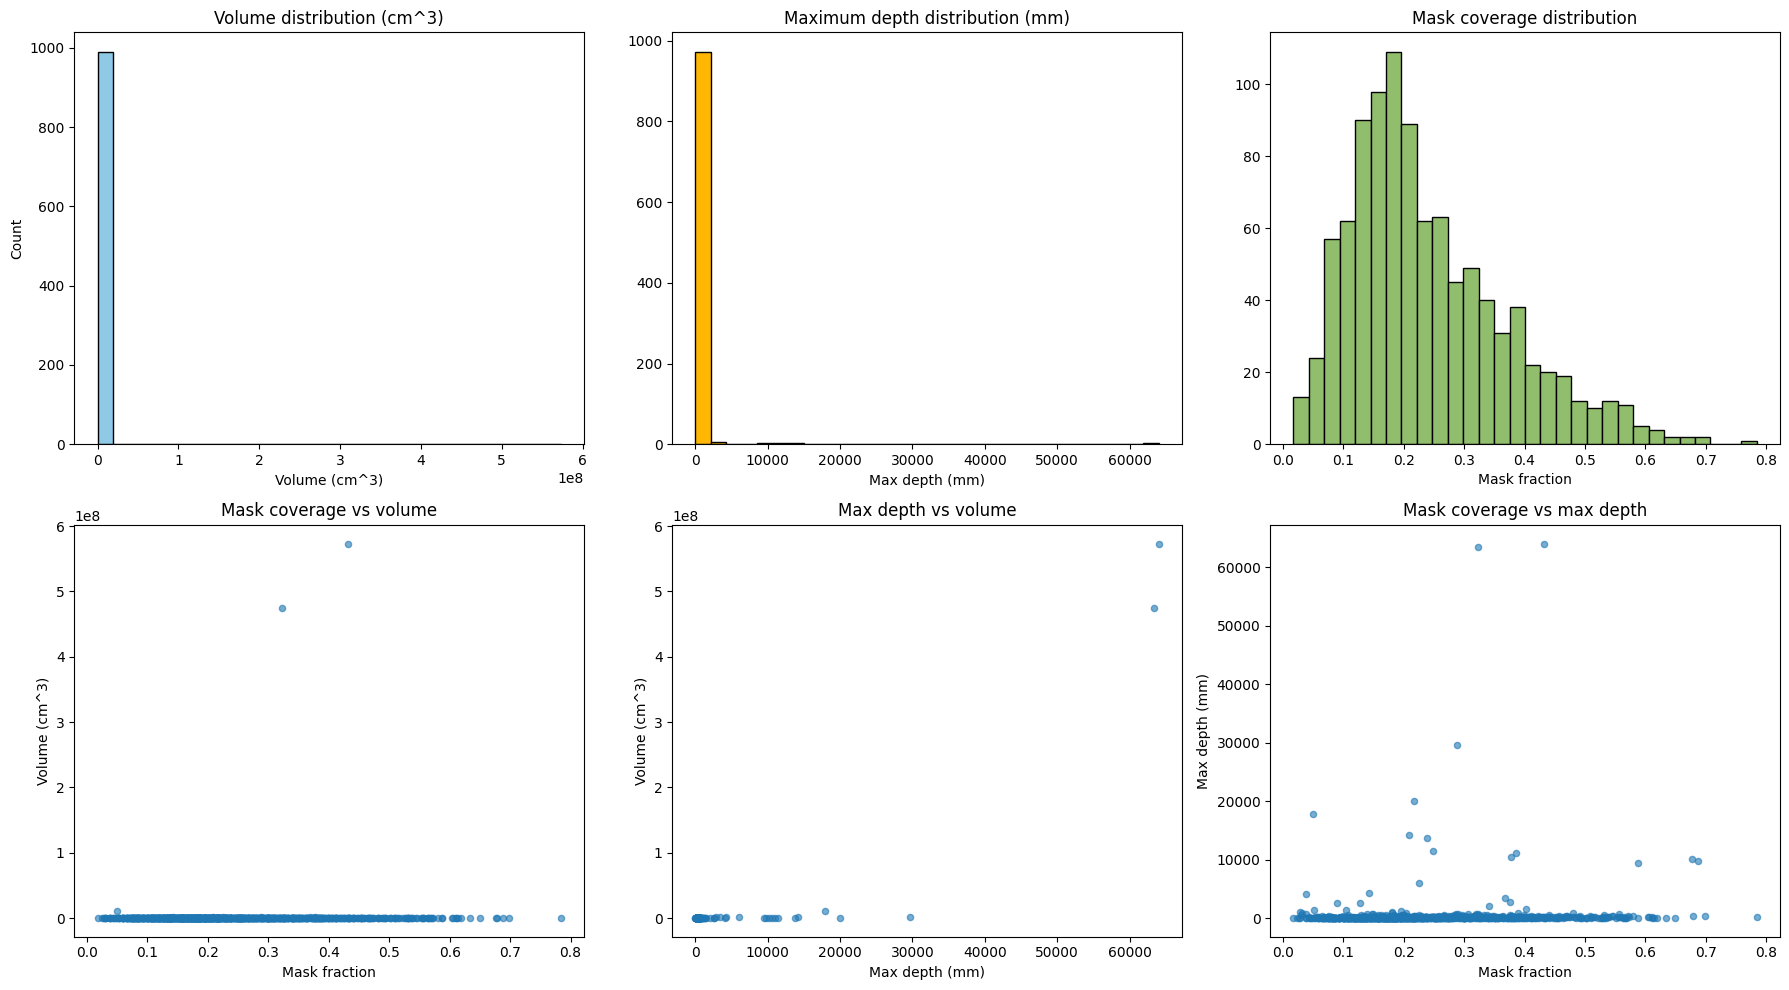

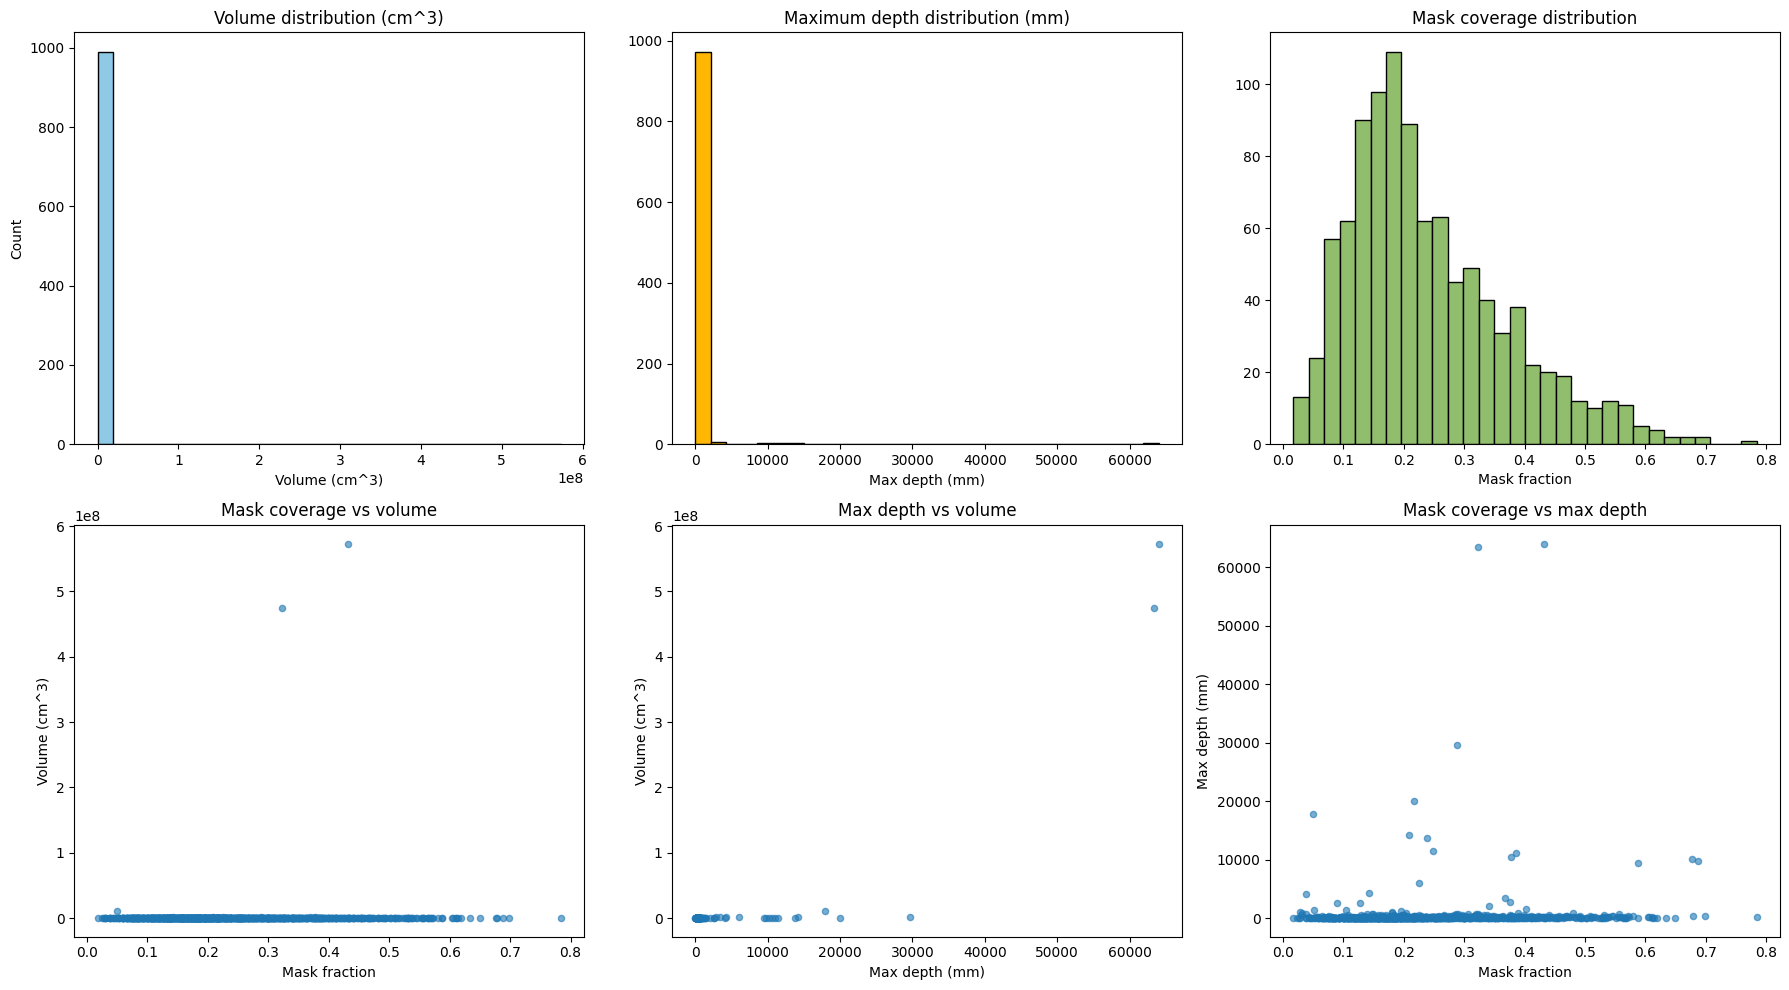

In [4]:
if metrics_df.empty:
    raise RuntimeError("No metrics were computed. Check the manifest and helper functions first.")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].hist(metrics_df["volume_cm3"], bins=30, color="#8ecae6", edgecolor="black")
axes[0, 0].set_title("Volume distribution (cm^3)")
axes[0, 0].set_xlabel("Volume (cm^3)")
axes[0, 0].set_ylabel("Count")

axes[0, 1].hist(metrics_df["max_depth_mm"], bins=30, color="#ffb703", edgecolor="black")
axes[0, 1].set_title("Maximum depth distribution (mm)")
axes[0, 1].set_xlabel("Max depth (mm)")

axes[0, 2].hist(metrics_df["mask_fraction"], bins=30, color="#90be6d", edgecolor="black")
axes[0, 2].set_title("Mask coverage distribution")
axes[0, 2].set_xlabel("Mask fraction")

axes[1, 0].scatter(metrics_df["mask_fraction"], metrics_df["volume_cm3"], alpha=0.6, s=20)
axes[1, 0].set_title("Mask coverage vs volume")
axes[1, 0].set_xlabel("Mask fraction")
axes[1, 0].set_ylabel("Volume (cm^3)")

axes[1, 1].scatter(metrics_df["max_depth_mm"], metrics_df["volume_cm3"], alpha=0.6, s=20)
axes[1, 1].set_title("Max depth vs volume")
axes[1, 1].set_xlabel("Max depth (mm)")
axes[1, 1].set_ylabel("Volume (cm^3)")

axes[1, 2].scatter(metrics_df["mask_fraction"], metrics_df["max_depth_mm"], alpha=0.6, s=20)
axes[1, 2].set_title("Mask coverage vs max depth")
axes[1, 2].set_xlabel("Mask fraction")
axes[1, 2].set_ylabel("Max depth (mm)")

fig.tight_layout()
fig

Percentile thresholds:
volume p90=49784.27 cm^3 | p95=93570.97 cm^3
max_depth p90=302.70 mm | p95=522.05 mm
Samples kept (p95 zoom): 929 / 992
Samples kept (p90 zoom): 870 / 992


(<Figure size 1800x500 with 3 Axes>,
 <Figure size 1800x500 with 3 Axes>,
 <Figure size 1200x400 with 2 Axes>)

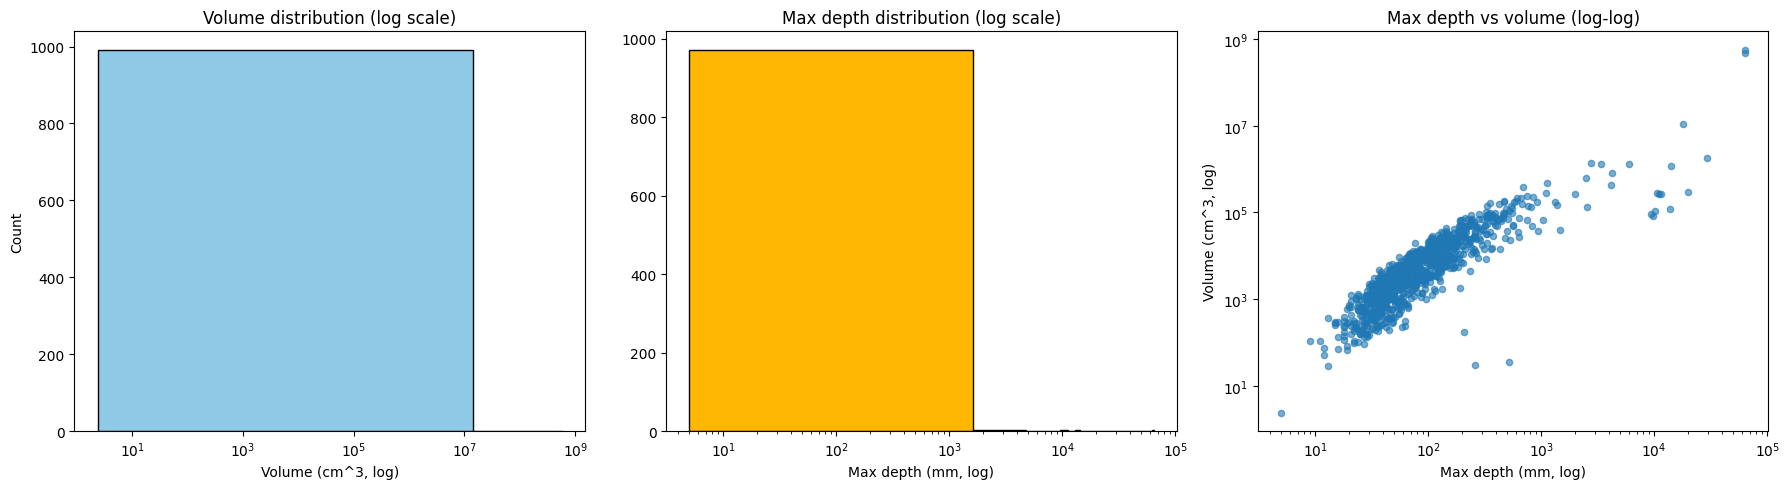

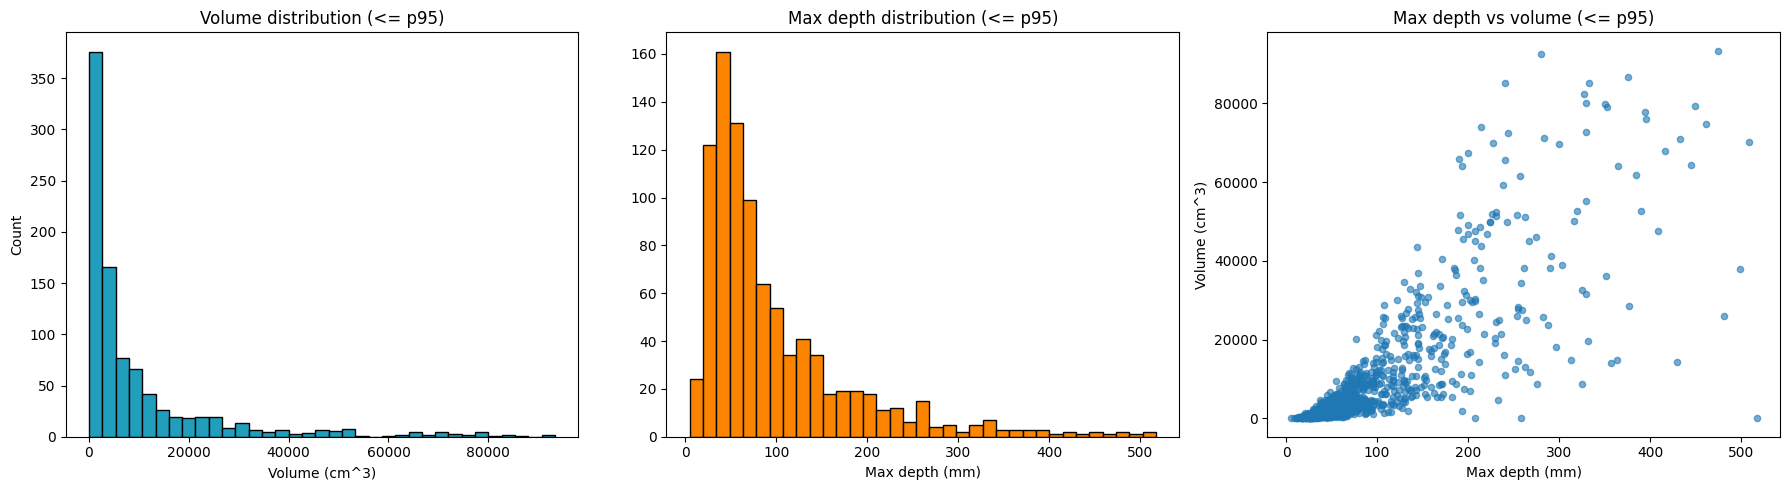

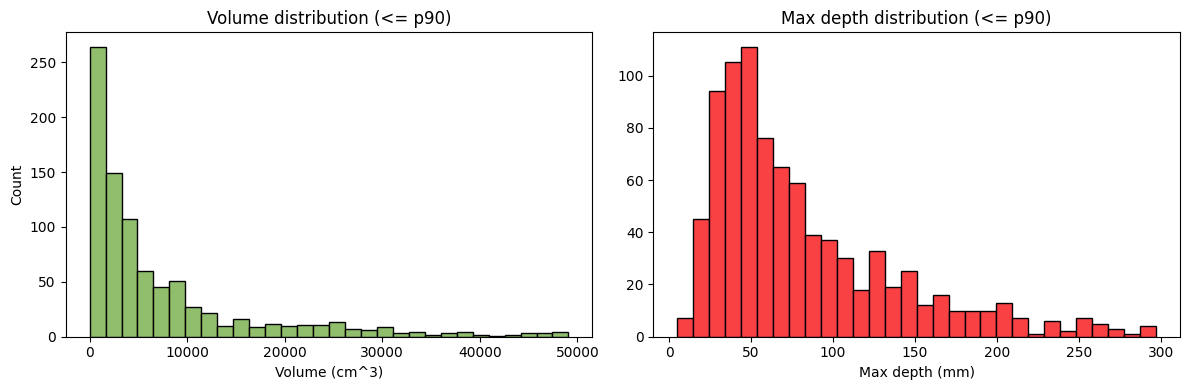

In [5]:
# Alternative visualizations robust to outliers
if metrics_df.empty:
    raise RuntimeError("No metrics available. Run previous cells first.")

plot_df = metrics_df.copy()
plot_df = plot_df[(plot_df["volume_cm3"] > 0) & (plot_df["max_depth_mm"] > 0)].copy()

# Percentile thresholds for zoomed views
vol_p90 = float(plot_df["volume_cm3"].quantile(0.90))
vol_p95 = float(plot_df["volume_cm3"].quantile(0.95))
depth_p90 = float(plot_df["max_depth_mm"].quantile(0.90))
depth_p95 = float(plot_df["max_depth_mm"].quantile(0.95))

zoom_p95 = plot_df[(plot_df["volume_cm3"] <= vol_p95) & (plot_df["max_depth_mm"] <= depth_p95)].copy()
zoom_p90 = plot_df[(plot_df["volume_cm3"] <= vol_p90) & (plot_df["max_depth_mm"] <= depth_p90)].copy()

print("Percentile thresholds:")
print(f"volume p90={vol_p90:.2f} cm^3 | p95={vol_p95:.2f} cm^3")
print(f"max_depth p90={depth_p90:.2f} mm | p95={depth_p95:.2f} mm")
print(f"Samples kept (p95 zoom): {len(zoom_p95)} / {len(plot_df)}")
print(f"Samples kept (p90 zoom): {len(zoom_p90)} / {len(plot_df)}")

# 1) Log-scale visualizations
fig_log, axes_log = plt.subplots(1, 3, figsize=(18, 5))

axes_log[0].hist(plot_df["volume_cm3"], bins=40, color="#8ecae6", edgecolor="black")
axes_log[0].set_xscale("log")
axes_log[0].set_title("Volume distribution (log scale)")
axes_log[0].set_xlabel("Volume (cm^3, log)")
axes_log[0].set_ylabel("Count")

axes_log[1].hist(plot_df["max_depth_mm"], bins=40, color="#ffb703", edgecolor="black")
axes_log[1].set_xscale("log")
axes_log[1].set_title("Max depth distribution (log scale)")
axes_log[1].set_xlabel("Max depth (mm, log)")

axes_log[2].scatter(plot_df["max_depth_mm"], plot_df["volume_cm3"], alpha=0.6, s=20)
axes_log[2].set_xscale("log")
axes_log[2].set_yscale("log")
axes_log[2].set_title("Max depth vs volume (log-log)")
axes_log[2].set_xlabel("Max depth (mm, log)")
axes_log[2].set_ylabel("Volume (cm^3, log)")

fig_log.tight_layout()

# 2) Zoomed (p95) visualizations
fig_p95, axes_p95 = plt.subplots(1, 3, figsize=(18, 5))

axes_p95[0].hist(zoom_p95["volume_cm3"], bins=35, color="#219ebc", edgecolor="black")
axes_p95[0].set_title("Volume distribution (<= p95)")
axes_p95[0].set_xlabel("Volume (cm^3)")
axes_p95[0].set_ylabel("Count")

axes_p95[1].hist(zoom_p95["max_depth_mm"], bins=35, color="#fb8500", edgecolor="black")
axes_p95[1].set_title("Max depth distribution (<= p95)")
axes_p95[1].set_xlabel("Max depth (mm)")

axes_p95[2].scatter(zoom_p95["max_depth_mm"], zoom_p95["volume_cm3"], alpha=0.6, s=20)
axes_p95[2].set_title("Max depth vs volume (<= p95)")
axes_p95[2].set_xlabel("Max depth (mm)")
axes_p95[2].set_ylabel("Volume (cm^3)")

fig_p95.tight_layout()

# Optional: keep p90 frame for even tighter visual exploration
fig_p90, axes_p90 = plt.subplots(1, 2, figsize=(12, 4))
axes_p90[0].hist(zoom_p90["volume_cm3"], bins=30, color="#90be6d", edgecolor="black")
axes_p90[0].set_title("Volume distribution (<= p90)")
axes_p90[0].set_xlabel("Volume (cm^3)")
axes_p90[0].set_ylabel("Count")

axes_p90[1].hist(zoom_p90["max_depth_mm"], bins=30, color="#f94144", edgecolor="black")
axes_p90[1].set_title("Max depth distribution (<= p90)")
axes_p90[1].set_xlabel("Max depth (mm)")

fig_p90.tight_layout()

fig_log, fig_p95, fig_p90

Top candidate outliers: ['20250305_110443', '20250305_125803']
20250305_110443 -> volume_cm3=573282173.97 max_depth_mm=64046.00 surface_area_cm2=115257.95
20250305_125803 -> volume_cm3=474512671.05 max_depth_mm=63408.00 surface_area_cm2=76925.14


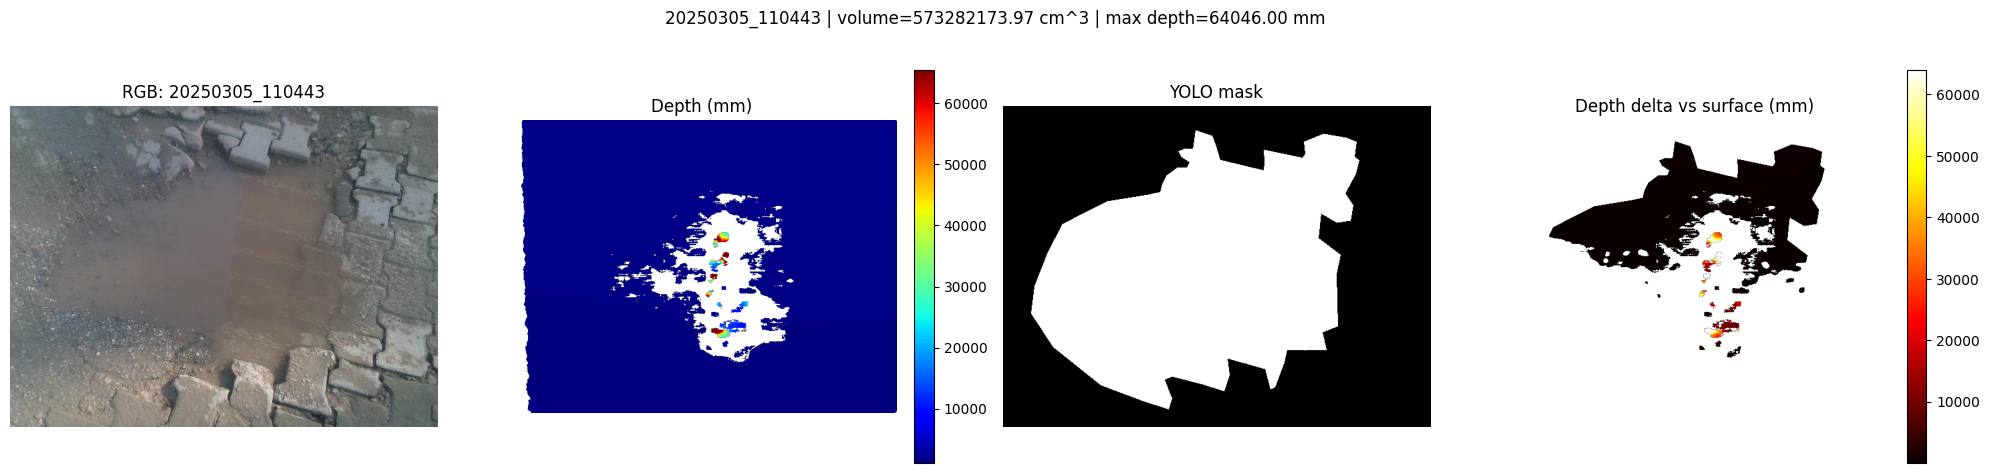

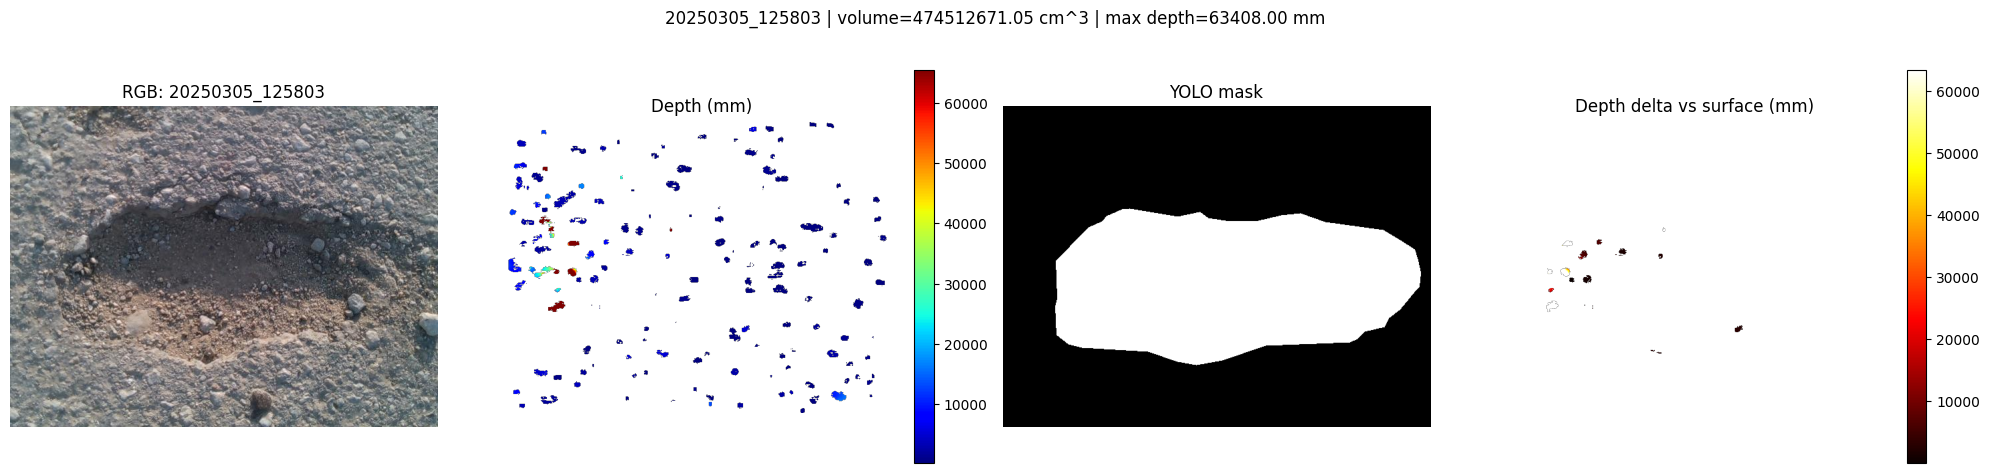

In [6]:
def visualize_sample(sample_id: str):
    row = manifest.loc[manifest["sample_id"] == sample_id].iloc[0]
    image_path = dataset_root / row["image_path"]
    depth_path = dataset_root / row["depth_path"]
    label_path = dataset_root / row["label_path"]

    image = np.array(Image.open(image_path).convert("RGB"))
    depth = np.load(depth_path)
    mask = load_yolo_mask(label_path, image_shape=depth.shape)

    road_surface = estimate_road_surface_depth(depth, mask)
    if road_surface is None:
        raise RuntimeError(f"Could not estimate road surface for {sample_id}")

    metrics = calculate_volume_variable_area(depth, mask, road_surface, camera=camera)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(image)
    axes[0].set_title(f"RGB: {sample_id}")
    axes[0].axis("off")

    depth_vis = depth.astype(np.float32)
    depth_vis[depth_vis == 0] = np.nan
    im_depth = axes[1].imshow(depth_vis, cmap="jet")
    axes[1].set_title("Depth (mm)")
    axes[1].axis("off")
    fig.colorbar(im_depth, ax=axes[1], fraction=0.046, pad=0.04)

    axes[2].imshow(mask, cmap="gray")
    axes[2].set_title("YOLO mask")
    axes[2].axis("off")

    diff_map = metrics["depth_diff_map"].copy().astype(np.float32)
    diff_map[diff_map == 0] = np.nan
    im_diff = axes[3].imshow(diff_map, cmap="hot")
    axes[3].set_title("Depth delta vs surface (mm)")
    axes[3].axis("off")
    fig.colorbar(im_diff, ax=axes[3], fraction=0.046, pad=0.04)

    fig.suptitle(
        f"{sample_id} | volume={metrics['volume_cm3']:.2f} cm^3 | max depth={metrics['max_depth_mm']:.2f} mm"
    )
    fig.tight_layout()
    return fig, metrics

if not metrics_df.empty:
    top_volume = metrics_df.sort_values("volume_cm3", ascending=False).head(2)["sample_id"].tolist()
    top_depth = metrics_df.sort_values("max_depth_mm", ascending=False).head(2)["sample_id"].tolist()
    outlier_samples = list(dict.fromkeys(top_volume + top_depth))

    print("Top candidate outliers:", outlier_samples)
    for sample_id in outlier_samples[:2]:
        fig, metrics = visualize_sample(sample_id)
        print(
            sample_id,
            "->",
            f"volume_cm3={metrics['volume_cm3']:.2f}",
            f"max_depth_mm={metrics['max_depth_mm']:.2f}",
            f"surface_area_cm2={metrics['surface_area_cm2']:.2f}",
        )
        fig

## Notes and next questions
Cautions:
- the D415 intrinsics are approximate, the original paper did not specify them.

In [7]:
# Consolidated EDA outputs: summary table + exports + outlier flags
if metrics_df.empty:
    raise RuntimeError("metrics_df is empty. Run previous cells first.")

interim_dir = code_root / "data" / "interim"
reports_dir = code_root / "reports"
interim_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

summary_stats = {
    "samples_computed": int(len(metrics_df)),
    "samples_failed": int(len(failures)),
    "volume_cm3_median": float(metrics_df["volume_cm3"].median()),
    "volume_cm3_p95": float(metrics_df["volume_cm3"].quantile(0.95)),
    "max_depth_mm_median": float(metrics_df["max_depth_mm"].median()),
    "max_depth_mm_p95": float(metrics_df["max_depth_mm"].quantile(0.95)),
    "mask_fraction_median": float(metrics_df["mask_fraction"].median()),
    "mask_fraction_p95": float(metrics_df["mask_fraction"].quantile(0.95)),
    "missing_depth_fraction_mean": float(metrics_df["missing_depth_fraction"].mean()),
}

# IQR-based outlier tagging for relative anomaly detection (using log scale).
outlier_df = metrics_df.copy()
outlier_df["volume_outlier_iqr"] = False
outlier_df["depth_outlier_iqr"] = False

for col, flag_col in [("volume_cm3", "volume_outlier_iqr"), ("max_depth_mm", "depth_outlier_iqr")]:
    log_vals = np.log1p(outlier_df[col])
    q1 = log_vals.quantile(0.25)
    q3 = log_vals.quantile(0.75)
    iqr = q3 - q1
    upper_log = q3 + 1.5 * iqr
    outlier_df[flag_col] = log_vals > upper_log

# Hard plausibility checks to expose likely sensor/depth corruption.
outlier_df["depth_implausible_gt_5000mm"] = outlier_df["max_depth_mm"] > 5000
outlier_df["volume_implausible_gt_1e6_cm3"] = outlier_df["volume_cm3"] > 1_000_000
outlier_df["quality_flag"] = (
    outlier_df[[
        "volume_outlier_iqr",
        "depth_outlier_iqr",
        "depth_implausible_gt_5000mm",
        "volume_implausible_gt_1e6_cm3",
    ]]
    .any(axis=1)
)

metrics_csv = interim_dir / "pothrgbd_eda_metrics.csv"
outliers_csv = interim_dir / "pothrgbd_eda_outliers.csv"
summary_json = reports_dir / "pothrgbd_eda_summary.json"

metrics_df.to_csv(metrics_csv, index=False)
outlier_df.to_csv(outliers_csv, index=False)
summary_json.write_text(json.dumps(summary_stats, indent=2), encoding="utf-8")

print("=== EDA Summary ===")
for k, v in summary_stats.items():
    print(f"{k}: {v}")

flagged = outlier_df[outlier_df["quality_flag"]].copy()
print(f"\nFlagged samples: {len(flagged)}")
if not flagged.empty:
    cols = [
        "sample_id",
        "volume_cm3",
        "max_depth_mm",
        "volume_outlier_iqr",
        "depth_outlier_iqr",
        "depth_implausible_gt_5000mm",
        "volume_implausible_gt_1e6_cm3",
    ]
    print(flagged[cols].sort_values(["depth_implausible_gt_5000mm", "volume_cm3"], ascending=[False, False]).head(10).to_string(index=False))

print("\nSaved files:")
print(f"- {metrics_csv}")
print(f"- {outliers_csv}")
print(f"- {summary_json}")

=== EDA Summary ===
samples_computed: 992
samples_failed: 4
volume_cm3_median: 4464.163149798909
volume_cm3_p95: 93570.96575251235
max_depth_mm_median: 72.0
max_depth_mm_p95: 522.0499999999994
mask_fraction_median: 0.20881998697916665
mask_fraction_p95: 0.50137939453125
missing_depth_fraction_mean: 0.01666466344235791

Flagged samples: 29
      sample_id   volume_cm3  max_depth_mm  volume_outlier_iqr  depth_outlier_iqr  depth_implausible_gt_5000mm  volume_implausible_gt_1e6_cm3
20250305_110443 5.732822e+08       64046.0                True               True                         True                           True
20250305_125803 4.745127e+08       63408.0                True               True                         True                           True
20250305_143424 1.069795e+07       17876.0                True               True                         True                           True
20250305_131835 1.764100e+06       29615.0                True               True          